# GAM Interactions: Tensor Products and Factor-Smooth Terms

## Overview

Standard GAMs are **additive** — each predictor's effect is modeled independently and summed. When the effect of one predictor depends on the value of another, you need an **interaction smooth**.

| Term | Syntax | Use Case |
|---|---|---|
| **Tensor product smooth** | `te(x1, x2)` | Interaction between two continuous predictors on potentially different scales |
| **Tensor product interaction** | `ti(x1, x2)` | Pure interaction component only (main effects modeled separately) |
| **Isotropic smooth** | `s(x1, x2)` | 2D smooth when both predictors are on the same scale (e.g., spatial coordinates) |
| **Factor-smooth interaction** | `s(x, by = f)` | Different smooth of x for each level of factor f |
| **Random slope smooth** | `s(x, subject, bs = "fs")` | Subject-specific smooth deviations (GAMM context) |

> **`te()` vs `s(x1, x2)`:**  
> Use `s(x1, x2)` only when both predictors are on the same scale and isotropic smoothing is appropriate (e.g., spatial lat/lon).  
> Use `te()` for predictors on different scales (e.g., temperature and depth) — it uses separate marginal smooths with independent smoothing parameters.

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | How does species abundance vary across both depth and temperature simultaneously? Spatial distribution modeling (lat × lon). Does the seasonal pattern in bird counts differ between habitat types? |
| **Healthcare** | How does drug effect vary across both age and dose simultaneously? Does the temporal trend in readmission differ by hospital type? |
| **Finance** | How does default risk vary across both loan amount and term length? Does the relationship between interest rate and prepayment differ by loan type? |
| **Insurance** | How does claim frequency vary across both age and vehicle value? Does the seasonal claims pattern differ by policy region? |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(mgcv)
library(gratia)

set.seed(42)
n <- 400

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'mgcv' was built under R version 4.4.3"
Loading required package: nlme


Attaching package: 'nlme'


The fo

## Data

We simulate two datasets:
1. **Species abundance** across depth × temperature — a true 2D interaction surface
2. **Claims data** with different seasonal patterns by region — a factor-smooth interaction

In [3]:
# ── 2D surface: species abundance across depth × temperature ──────────────────
surface_data <- tibble(
  depth  = runif(n, 0, 50),
  temp   = runif(n, 5, 25),
  log_mu = 3 - 0.04 * depth - 0.05 * (temp - 18)^2 +
            0.003 * depth * (temp - 10),
  abundance = MASS::rnegbin(n, mu = exp(log_mu), theta = 3)
) %>% select(-log_mu)

# ── Factor-smooth: seasonal claims pattern by region ─────────────────────────
# Use rep_len() to guarantee the month vector is exactly length n
# regardless of whether n is divisible by 12
seasonal_data <- tibble(
  month  = rep_len(1:12, n),
  region = sample(c("North", "South", "Central"), n, replace = TRUE),
  mu = case_when(
    region == "North"   ~ exp(2 + 0.3 * cos(2 * pi * month / 12)),
    region == "South"   ~ exp(2 - 0.3 * cos(2 * pi * month / 12)),
    region == "Central" ~ exp(2 + 0.1 * sin(2 * pi * month / 12))
  ),
  claims = rpois(n, lambda = mu)
) %>% select(-mu)

cat("Surface data:\n"); glimpse(surface_data)
cat("\nSeasonal data:\n"); glimpse(seasonal_data)

Surface data:
Rows: 400
Columns: 3
$ depth     <dbl> 1.754204, 5.651903, 34.390178, 4.004846, 15.788279, 38.22340…
$ temp      <dbl> 8.789699, 7.014252, 9.341155, 8.890325, 6.212267, 24.408378,…
$ abundance <int> 0, 0, 0, 0, 0, 1, 0, 21, 2, 2, 18, 0, 0, 1, 4, 7, 4, 0, 0, 0…

Seasonal data:
Rows: 400
Columns: 3
$ month  <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, …
$ region <chr> "North", "South", "North", "North", "North", "South", "North", …
$ claims <int> 14, 10, 8, 7, 2, 12, 6, 3, 5, 13, 3, 2, 10, 7, 9, 5, 8, 9, 11, …


---

## Tensor Product Smooth: `te(x1, x2)`

Fits a smooth surface over two continuous predictors. Each predictor gets its own marginal smoothing parameter, making it appropriate when predictors are on different scales.

In [4]:
# ── Additive model (no interaction) for comparison ───────────────────────────
gam_add <- mgcv::gam(
  abundance ~ s(depth) + s(temp),
  data   = surface_data,
  family = mgcv::nb(),
  method = "REML"
)

# ── Tensor product: full interaction surface ──────────────────────────────────
gam_te <- mgcv::gam(
  abundance ~ te(depth, temp),  # single smooth surface over both predictors
  data   = surface_data,
  family = mgcv::nb(),
  method = "REML"
)
summary(gam_te)

# ── Main effects + interaction decomposition (preferred approach) ─────────────
# ti() fits the pure interaction term; main effects are modeled separately as s()
# This makes the model more interpretable: main effects + interaction component
gam_ti <- mgcv::gam(
  abundance ~ s(depth) + s(temp) + ti(depth, temp),
  data   = surface_data,
  family = mgcv::nb(),
  method = "REML"
)
summary(gam_ti)
# If ti(depth, temp) is significant: interaction is needed
# If not significant: additive model is sufficient

# ── Compare additive vs. interaction model ────────────────────────────────────
AIC(gam_add, gam_te, gam_ti)


Family: Negative Binomial(2.938) 
Link function: log 

Formula:
abundance ~ te(depth, temp)

Parametric coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.5028     0.1188   4.233 2.31e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                 edf Ref.df Chi.sq p-value    
te(depth,temp) 9.784  11.47  476.9  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.558   Deviance explained = 73.4%
-REML = 841.73  Scale est. = 1         n = 400


Family: Negative Binomial(2.973) 
Link function: log 

Formula:
abundance ~ s(depth) + s(temp) + ti(depth, temp)

Parametric coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.4726     0.1226   3.855 0.000116 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                 edf Ref.df Chi.sq  p-value    
s(depth)       1.001  1.002  22.17 3.24e-06 ***
s(temp)        5.521  6.565 424.25  < 2e-16 ***
ti(depth,temp) 3.675  5.264  26.24 0.000118 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.559   Deviance explained = 73.6%
-REML =  843.1  Scale est. = 1         n = 400

,df,AIC
,<dbl>,<dbl>
gam_add,8.525035,1697.154
gam_te,13.472074,1680.595
gam_ti,14.676715,1680.403


### Visualizing the Interaction Surface

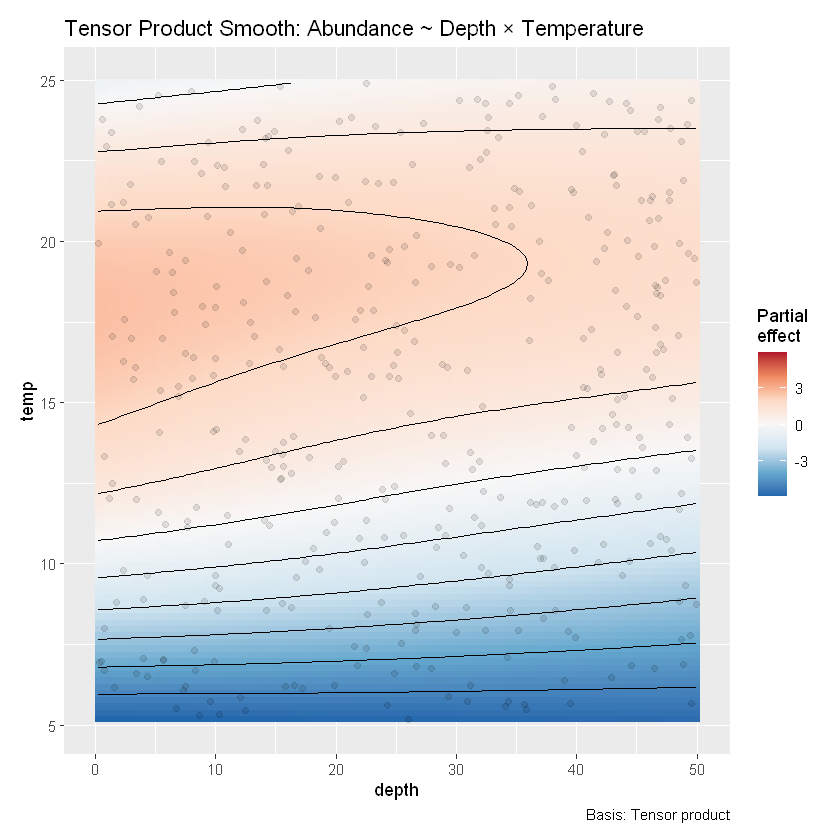

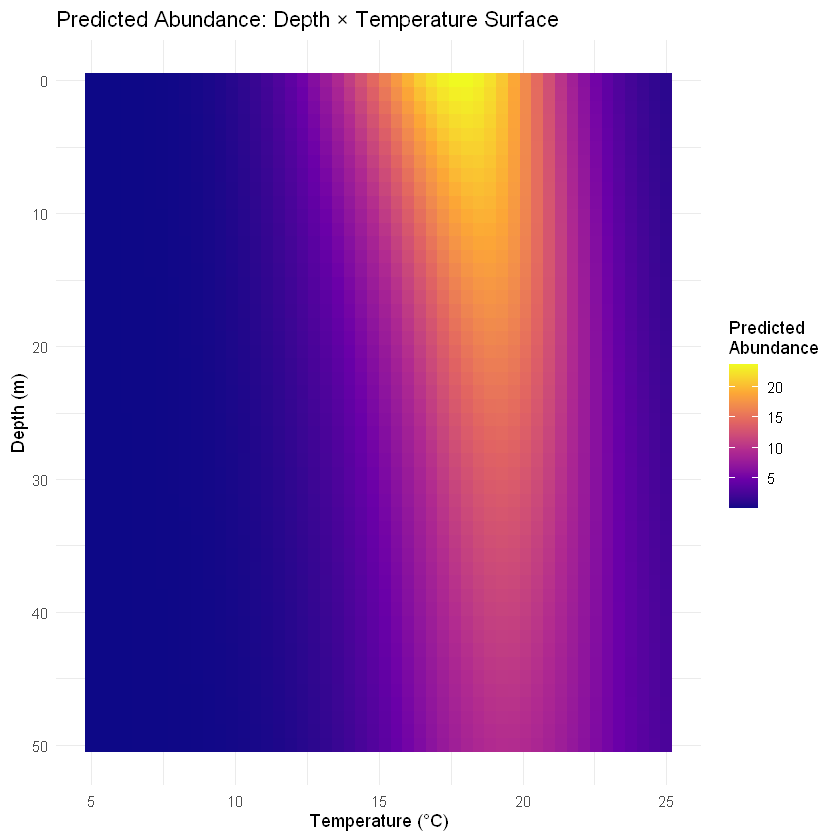

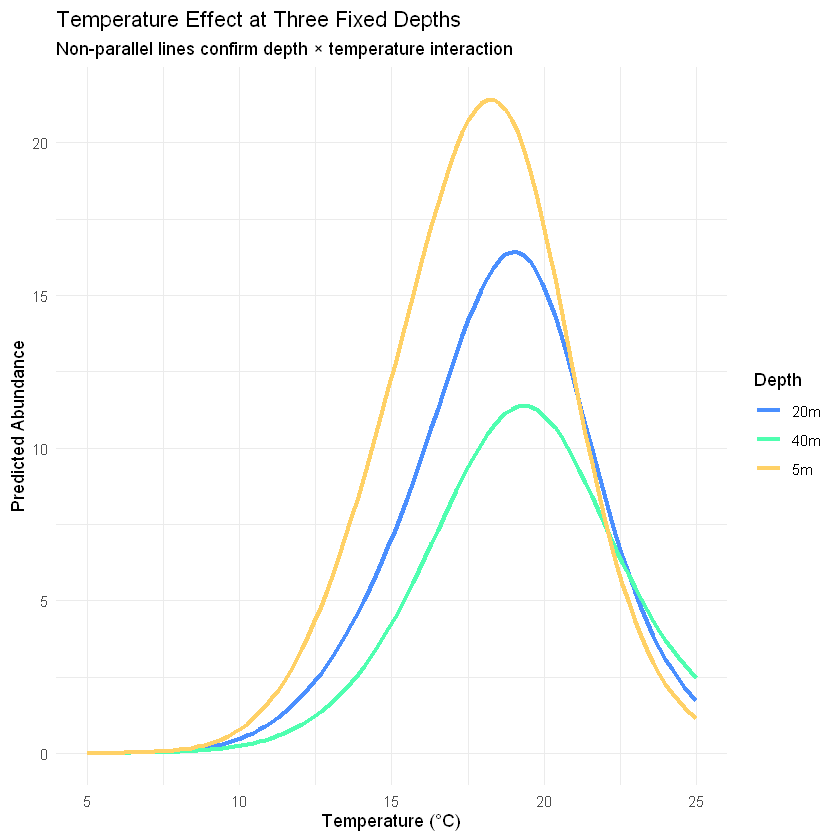

In [5]:
# ── gratia::draw() for tensor product ────────────────────────────────────────
gratia::draw(gam_te) +
  labs(title = "Tensor Product Smooth: Abundance ~ Depth × Temperature")
# Contour/filled contour plot showing the 2D smooth surface

# ── Manual prediction grid: heatmap ──────────────────────────────────────────
pred_surface <- expand.grid(
  depth = seq(0,  50, length.out = 50),
  temp  = seq(5,  25, length.out = 50)
) %>%
  mutate(pred = predict(gam_te, newdata = ., type = "response"))

ggplot(pred_surface, aes(x = temp, y = depth, fill = pred)) +
  geom_tile() +
  scale_fill_viridis_c(option = "plasma") +
  scale_y_reverse() +  # depth increases downward
  labs(title = "Predicted Abundance: Depth × Temperature Surface",
       x = "Temperature (°C)", y = "Depth (m)",
       fill = "Predicted\nAbundance") +
  theme_minimal()

# ── Slice plot: effect of temp at fixed depths ────────────────────────────────
slice_data <- expand.grid(
  depth = c(5, 20, 40),
  temp  = seq(5, 25, length.out = 100)
) %>%
  mutate(
    pred  = predict(gam_te, newdata = ., type = "response"),
    depth_f = factor(paste0(depth, "m"))
  )

ggplot(slice_data, aes(x = temp, y = pred, color = depth_f)) +
  geom_line(linewidth = 1.2) +
  scale_color_manual(values = c("#4a8fff", "#4fffb0", "#ffd166")) +
  labs(title = "Temperature Effect at Three Fixed Depths",
       subtitle = "Non-parallel lines confirm depth × temperature interaction",
       x = "Temperature (°C)", y = "Predicted Abundance", color = "Depth") +
  theme_minimal()

---

## Factor-Smooth Interaction: `s(x, by = f)`

Fits a separate smooth of x for each level of a factor. Use when the shape of a continuous relationship plausibly differs across groups.


Family: poisson 
Link function: log 

Formula:
claims ~ region + s(month, bs = "cc") + s(month, by = region_ord, 
    bs = "cc")

Parametric coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.04272    0.03192  63.989   <2e-16 ***
regionNorth -0.10466    0.04474  -2.339   0.0193 *  
regionSouth -0.11439    0.04758  -2.404   0.0162 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                           edf Ref.df Chi.sq  p-value    
s(month)                 2.215      8  9.102  0.00226 ** 
s(month):region_ordNorth 3.645      8 50.377  < 2e-16 ***
s(month):region_ordSouth 2.912      8 21.834 3.13e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.201   Deviance explained = 22.1%
-REML = 1004.2  Scale est. = 1         n = 400

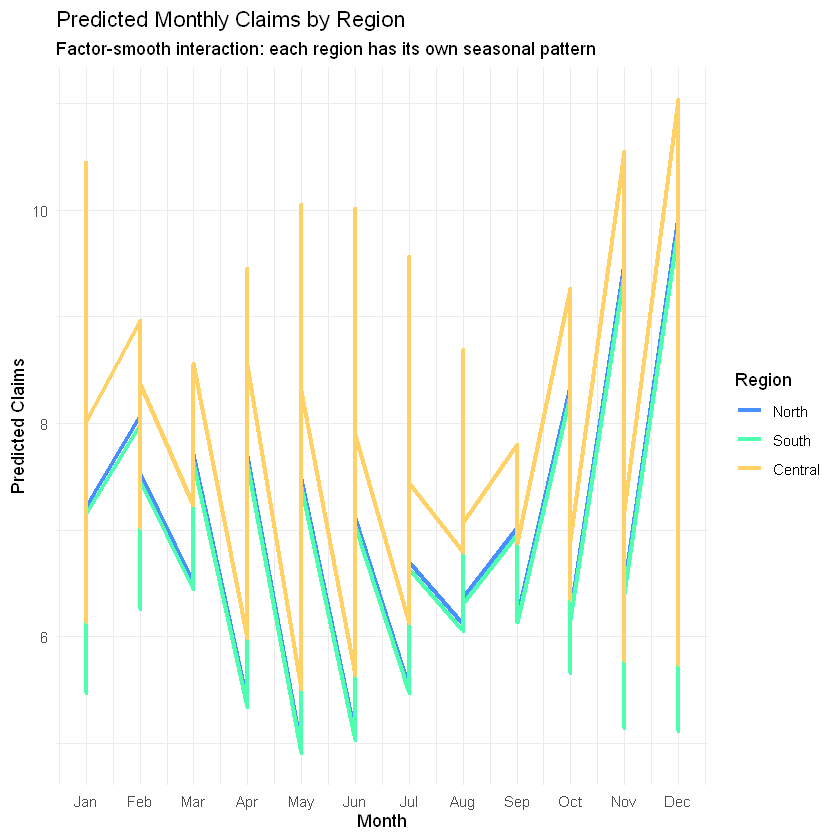

In [6]:
# ── Factor must be an ordered factor for difference smooths ───────────────────
# Ordered factor: tests whether smooths for non-reference levels DIFFER from reference
# Unordered factor: fits completely separate smooth per level
seasonal_data$region_ord <- factor(
  seasonal_data$region,
  levels = c("Central", "North", "South"),  # Central = reference
  ordered = TRUE
)

# ── Model with factor-smooth interaction ─────────────────────────────────────
# Ordered factor approach: tests difference smooths
gam_fs <- mgcv::gam(
  claims ~ region +                           # parametric main effect of region
            s(month, bs = "cc") +             # reference smooth (Central)
            s(month, by = region_ord,          # difference smooths for North, South
              bs = "cc"),
  data   = seasonal_data,
  family = poisson,
  method = "REML",
  knots  = list(month = c(0.5, 12.5))  # wrap cyclic spline at year boundaries
)
summary(gam_fs)
# Significant difference smooth: that region's seasonal pattern differs from Central

# ── Visualize: predicted seasonal patterns per region ────────────────────────
pred_seasonal <- expand.grid(
  month      = 1:12,
  region     = c("North", "South", "Central"),
  region_ord = factor(c("North", "South", "Central"),
                      levels = c("Central", "North", "South"), ordered = TRUE)
) %>%
  mutate(pred = predict(gam_fs, newdata = ., type = "response"))

ggplot(pred_seasonal, aes(x = month, y = pred, color = region)) +
  geom_line(linewidth = 1.2) +
  scale_color_manual(values = c("#4a8fff", "#4fffb0", "#ffd166")) +
  scale_x_continuous(breaks = 1:12,
                     labels = month.abb) +
  labs(title = "Predicted Monthly Claims by Region",
       subtitle = "Factor-smooth interaction: each region has its own seasonal pattern",
       x = "Month", y = "Predicted Claims", color = "Region") +
  theme_minimal()

---

## Spatial Smooths: `s(lon, lat)`

For spatial data where both coordinates are on the same scale (degrees), an isotropic 2D smooth is appropriate.


Family: gaussian 
Link function: identity 

Formula:
z ~ s(lon, lat, bs = "tp", k = 30)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 15.34499    0.04975   308.4   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf Ref.df     F p-value    
s(lon,lat) 22.42   26.6 74.51  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.832   Deviance explained = 84.2%
-REML = 595.88  Scale est. = 0.99021   n = 400

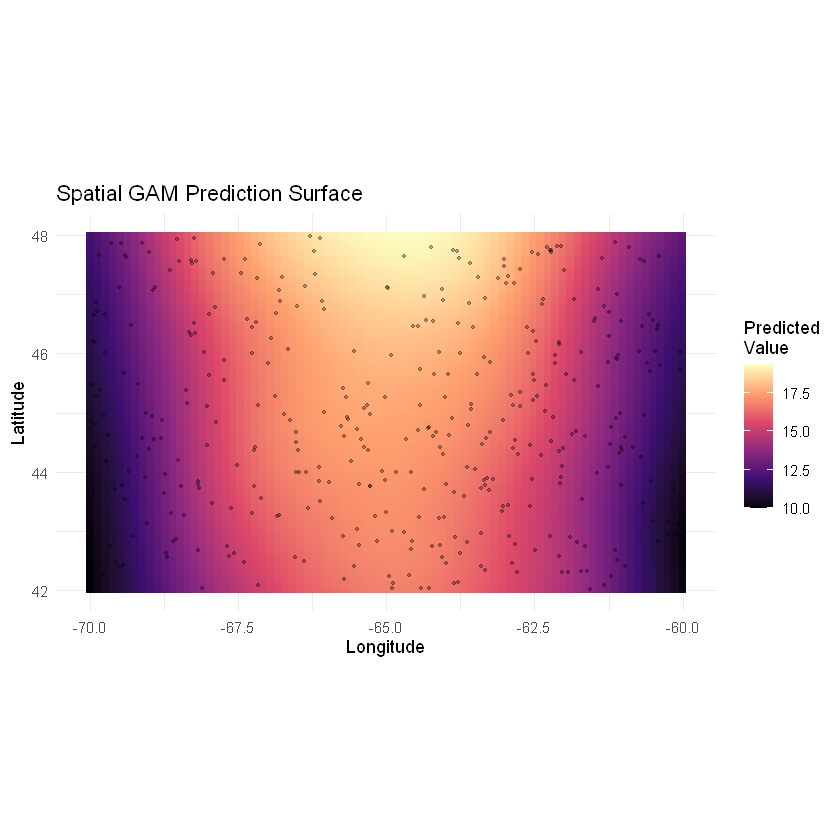

In [7]:
# ── Simulate spatial data ─────────────────────────────────────────────────────
spatial_data <- tibble(
  lon  = runif(n, -70, -60),
  lat  = runif(n, 42, 48),
  # Spatial gradient: higher values in NW corner
  z    = -0.3 * (lon + 65)^2 + 0.4 * lat + rnorm(n, 0, 1)
)

# ── Isotropic 2D smooth for spatial data ─────────────────────────────────────
# bs = "tp" (thin plate): good default for geographic coordinates
# bs = "ds" (duchon spline): alternative with good boundary properties
gam_spatial <- mgcv::gam(
  z ~ s(lon, lat, bs = "tp", k = 30),
  data   = spatial_data,
  method = "REML"
)
summary(gam_spatial)

# ── Prediction surface ────────────────────────────────────────────────────────
pred_map <- expand.grid(
  lon = seq(-70, -60, length.out = 80),
  lat = seq(42,  48,  length.out = 60)
) %>%
  mutate(pred = predict(gam_spatial, newdata = ., type = "response"))

ggplot(pred_map, aes(x = lon, y = lat, fill = pred)) +
  geom_tile() +
  geom_point(data = spatial_data, aes(fill = NULL), size = 0.8, alpha = 0.3) +
  scale_fill_viridis_c(option = "magma") +
  coord_equal() +
  labs(title = "Spatial GAM Prediction Surface",
       x = "Longitude", y = "Latitude", fill = "Predicted\nValue") +
  theme_minimal()

---

## Common Pitfalls

**1. Using `s(x1, x2)` for predictors on different scales**  
Isotropic smooths assume both predictors contribute equally per unit. Temperature (°C) and depth (m) are on incompatible scales — use `te()` which has separate smoothing parameters per predictor.

**2. Using `te()` instead of `s(x1, x2)` for geographic coordinates**  
Geographic lat/lon are on the same scale and an isotropic smooth is appropriate. `s(lon, lat)` is correct; `te(lon, lat)` will fit the surface as if the two axes are independent.

**3. Not including main effects when using `ti()`**  
`ti(x1, x2)` fits only the interaction component. You must explicitly add `s(x1) + s(x2)` to model the main effects. Omitting them means the interaction term absorbs the main effects, making interpretation difficult.

**4. Forgetting to use ordered factors for difference smooths**  
With unordered factors in `by=`, `mgcv` fits completely separate smooths per level. With ordered factors, it fits a reference smooth + deviation smooths — this is usually more interpretable and parsimonious.

**5. Using a linear cyclic smooth for non-cyclic predictors**  
`bs = "cc"` forces the smooth to be identical at both ends of the predictor range. Only use it for genuinely periodic data like months, time of day, or compass bearing.

**6. Not testing whether the interaction is significant**  
Always compare the interaction model (with `ti()`) to the additive model (with separate `s()` terms) using AIC. If ΔAIC < 2, the interaction is not supported and the simpler additive model should be preferred.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*